In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)



In [4]:
df_2015 = pd.read_csv('/home/domingossj/Downloads/recife_acidentes_transito/acidentes-transito-2015.csv')

In [14]:
daily_2015 = df_2015[df_2015['situacao'] == 'FINALIZADA'].groupby('data')['natureza_acidente'].count().reset_index() 
daily_2015.columns = ['date', 'y']

In [18]:
df_2016 = pd.read_csv('/home/domingossj/Downloads/recife_acidentes_transito/acidentes_2016.csv')

In [20]:
daily_2016 = df_2016[df_2016['situacao'] == 'FINALIZADA'].groupby('data')['natureza_acidente'].count().reset_index() 
daily_2016.columns = ['date', 'y']

In [23]:
df_2017 = pd.read_csv('/home/domingossj/Downloads/recife_acidentes_transito/acidentes_2017.csv')
daily_2017 = df_2017[df_2017['situacao'] == 'FINALIZADA'].groupby('data')['natureza_acidente'].count().reset_index() 
daily_2017.columns = ['date', 'y']

In [24]:
df_2018 = pd.read_csv('/home/domingossj/Downloads/recife_acidentes_transito/acidentes_2018.csv')

In [26]:
daily_2018 = df_2018[df_2018['situacao'] == 'FINALIZADA'].groupby('data')['natureza_acidente'].count().reset_index() 
daily_2018.columns = ['date', 'y']

In [27]:
df_2019 = pd.read_csv('/home/domingossj/Downloads/recife_acidentes_transito/acidentes-2019.csv')

In [29]:
daily_2019 = df_2019[df_2019['situacao'] == 'FINALIZADA'].groupby('data')['natureza_acidente'].count().reset_index() 
daily_2019.columns = ['date', 'y']

In [73]:
df= pd.concat([daily_2015, daily_2016, daily_2017, daily_2018, daily_2019])

<Axes: xlabel='date'>

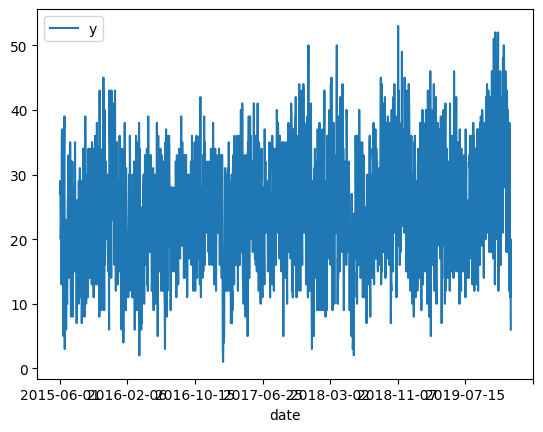

In [74]:
df.set_index('date').plot()

In [75]:
df_dates = pd.DataFrame({'date': pd.date_range(start=df['date'].min(), end=df['date'].max())})

In [76]:
df['date'] = pd.to_datetime(df['date'])

In [77]:
df_joined = df.merge(df_dates, how='right', on = 'date')
df_joined['weekday'] = df_joined['date'].dt.weekday

In [78]:
for dt in df_joined[df_joined['y'].isna()].to_dict('records'):
    date = dt['date']
    weekday = dt['weekday']
    last_values = df_joined[(df_joined['date'] < date) & (df_joined['weekday'] == weekday)].iloc[-4:]['y'].mean()

    df_joined.loc[df_joined['date'] == date, 'y'] = last_values

In [100]:
df_joined['y'].to_csv('recifeaccday.txt', index=False)

In [85]:
df_joined['month']= df_joined['date'].dt.month
df_joined['year']= df_joined['date'].dt.year
df_joined['week_year'] = df_joined['date'].dt.isocalendar().week + df_joined['date'].dt.isocalendar().year * 100


In [101]:
df_joined.groupby(['year', 'month'])['y'].sum().reset_index().to_csv('recifeaccmonth.txt', index=False)

In [102]:
df_joined.groupby(['week_year'])['y'].sum().reset_index().to_csv('recifeaccweek.txt', index=False)

<Axes: xlabel='week_year'>

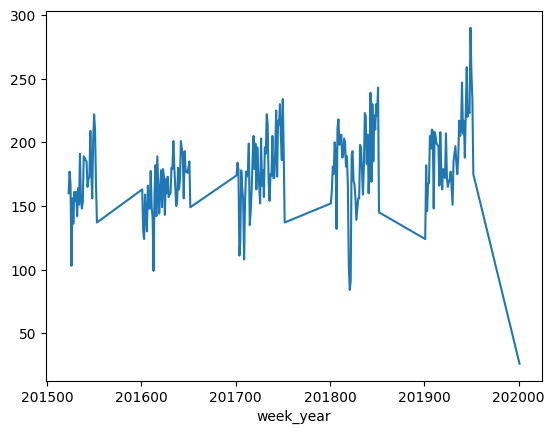

In [95]:
df_joined

,date,y,weekday,month,year,week,week_year
0,2015-06-01,27.0,0,6,2015,23,201523
1,2015-06-02,29.0,1,6,2015,23,201523
2,2015-06-03,28.0,2,6,2015,23,201523
3,2015-06-04,20.0,3,6,2015,23,201523
4,2015-06-05,22.0,4,6,2015,23,201523
...,...,...,...,...,...,...,...
1670,2019-12-27,29.0,4,12,2019,52,201952
1671,2019-12-28,22.0,5,12,2019,52,201952
1672,2019-12-29,11.0,6,12,2019,52,201952
1673,2019-12-30,20.0,0,12,2019,1,202001


In [18]:
df = pd.read_csv('/home/domingossj/Downloads/bigquery-geotab-intersection-congestion/test.csv')

In [20]:
df

,RowId,IntersectionId,Latitude,Longitude,EntryStreetName,ExitStreetName,EntryHeading,ExitHeading,Hour,Weekend,Month,Path,City
0,0,1,33.750940,-84.393032,Peachtree Street Southwest,Peachtree Street Southwest,NE,NE,0,0,6,Peachtree Street Southwest_NE_Peachtree Street...,Atlanta
1,1,1,33.750940,-84.393032,Peachtree Street Southwest,Mitchell Street Southwest,SW,SE,0,0,6,Peachtree Street Southwest_SW_Mitchell Street ...,Atlanta
2,2,1,33.750940,-84.393032,Peachtree Street Southwest,Peachtree Street Southwest,SW,SW,0,0,6,Peachtree Street Southwest_SW_Peachtree Street...,Atlanta
3,3,1,33.750940,-84.393032,Peachtree Street Southwest,Peachtree Street Southwest,NE,NE,1,0,6,Peachtree Street Southwest_NE_Peachtree Street...,Atlanta
4,4,1,33.750940,-84.393032,Peachtree Street Southwest,Peachtree Street Southwest,SW,SW,1,0,6,Peachtree Street Southwest_SW_Peachtree Street...,Atlanta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921352,1921352,1990,39.938232,-75.149930,South 4th Street,Catharine Street,S,W,20,1,12,South 4th Street_S_Catharine Street_W,Philadelphia
1921353,1921353,1990,39.938232,-75.149930,South 4th Street,South 4th Street,S,S,20,1,12,South 4th Street_S_South 4th Street_S,Philadelphia
1921354,1921354,1990,39.938232,-75.149930,South 4th Street,Catharine Street,S,W,21,1,12,South 4th Street_S_Catharine Street_W,Philadelphia
1921355,1921355,1990,39.938232,-75.149930,South 4th Street,South 4th Street,S,S,21,1,12,South 4th Street_S_South 4th Street_S,Philadelphia


In [16]:
count = 0
for k, i in df.groupby(['Latitude', 'Longitude', 'EntryStreetName', 'ExitStreetName', 'EntryHeading', 'ExitHeading', 'City']):
    if count>0:
        break

In [17]:
i.sort_values(by=['Month', 'Hour'])

,RowId,IntersectionId,Latitude,Longitude,EntryStreetName,ExitStreetName,EntryHeading,ExitHeading,Hour,Weekend,Month,Path,TotalTimeStopped_p20,TotalTimeStopped_p40,TotalTimeStopped_p50,TotalTimeStopped_p60,TotalTimeStopped_p80,TimeFromFirstStop_p20,TimeFromFirstStop_p40,TimeFromFirstStop_p50,TimeFromFirstStop_p60,TimeFromFirstStop_p80,DistanceToFirstStop_p20,DistanceToFirstStop_p40,DistanceToFirstStop_p50,DistanceToFirstStop_p60,DistanceToFirstStop_p80,City
239692,2161049,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,8,0,6,Wendell Street_W_Shepard Street_W,0.0,0.0,7.0,13.0,33.0,0.0,0.0,25.0,31.0,46.0,0.0,0.0,72.5,76.8,81.4,Boston
239701,2161058,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,10,0,6,Wendell Street_W_Shepard Street_W,0.0,0.0,0.0,24.0,40.0,0.0,0.0,0.0,37.0,56.0,0.0,0.0,0.0,66.8,79.3,Boston
239756,2161113,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,9,0,7,Wendell Street_W_Shepard Street_W,0.0,0.0,0.0,0.0,39.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0,0.0,64.7,Boston
239762,2161119,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,10,0,7,Wendell Street_W_Shepard Street_W,0.0,15.0,29.0,38.0,43.0,0.0,25.0,45.0,47.0,57.0,0.0,54.1,66.5,66.6,73.0,Boston
239816,2161173,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,8,0,8,Wendell Street_W_Shepard Street_W,0.0,0.0,0.0,35.0,56.0,0.0,0.0,0.0,48.0,69.0,0.0,0.0,0.0,61.2,69.2,Boston
239826,2161183,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,10,0,8,Wendell Street_W_Shepard Street_W,0.0,0.0,10.0,15.0,27.0,0.0,0.0,24.0,28.0,37.0,0.0,0.0,65.2,66.6,77.2,Boston
239831,2161188,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,11,0,8,Wendell Street_W_Shepard Street_W,0.0,0.0,0.0,23.0,55.0,0.0,0.0,0.0,33.0,64.0,0.0,0.0,0.0,65.2,94.1,Boston
239881,2161238,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,9,0,9,Wendell Street_W_Shepard Street_W,22.0,43.0,43.0,44.0,83.0,34.0,55.0,55.0,56.0,126.0,75.4,79.4,79.4,85.0,224.6,Boston
239886,2161243,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,10,0,9,Wendell Street_W_Shepard Street_W,0.0,0.0,0.0,11.0,12.0,0.0,0.0,0.0,20.0,27.0,0.0,0.0,0.0,49.7,79.6,Boston
239936,2161293,539,42.381782,-71.119735,Wendell Street,Shepard Street,W,W,8,0,10,Wendell Street_W_Shepard Street_W,11.0,14.0,14.0,16.0,17.0,24.0,25.0,28.0,29.0,31.0,71.5,73.4,74.5,80.5,101.6,Boston


In [8]:
df.groupby(['Latitude', 'Longitude', 'EntryStreetName', 'ExitStreetName', 'EntryHeading', 'ExitHeading']).count().shape

(22971, 22)